In [1]:
import json
import sys
sys.path.append("..")

import numpy as np
import matplotlib.pyplot as plt

from nanorods.geometry import build_nanorod_geometry
from nanorods.simulation import (
    nanorod_moment_of_inertia,
    line_displacement,
    run_simulation
)
from nanorods.visualization import plot_lattice

# Nanorod Superlattice Simulation

This notebook presents a two-dimensional numerical model for mechanical wave propagation in a nanorod superlattice.

Nanorods are treated as rigid bodies with translational and rotational degrees of freedom. Interactions between neighboring nanorods are modeled through ligand-mediated effective springs.

The simulation can generate longitudinal and transverse excitations propagating either parallel or perpendicular to the nanorod long axis.

## Physical model

The nanorod superlattice is modeled as a two-dimensional system of rigid nanorods connected through ligand-mediated springs.

Each nanorod has translational degrees of freedom along the $x$ and $y$ directions and a rotational degree of freedom around the $z$ axis. Its motion is therefore described by the center position

$$
\mathbf{r}_i = (x_i, y_i)
$$

and by the rotation angle $\theta_i$.

The interaction sites are distributed along the nanorod surface. Springs are created between sufficiently close sites belonging to neighboring nanorods. Multiple ligand connections between the same surface regions are treated as parallel springs and are represented by an effective spring constant

$$
k_{\mathrm{eff}} = N_{\mathrm{lig}} k_{\mathrm{lig}},
$$

where $N_{\mathrm{lig}}$ is the number of ligand connections and $k_{\mathrm{lig}}$ is the spring constant of a single ligand.

The nanorods are arranged in a staggered two-dimensional lattice with open boundary conditions.

## Nanorod geometry

Each nanorod is represented by a capsule-like shape consisting of a cylindrical section of length $L-d$ and two hemispherical end caps of radius

$$
r=\frac{d}{2}.
$$

The nanorods are arranged in a staggered FCC(111)-like lattice. The superlattice constants along the perpendicular and parallel directions are

$$
a_{\mathrm{SL},\perp}=d+s
$$

and

$$
a_{\mathrm{SL},\parallel}=(L-d)+\frac{\sqrt{3}}{2}(d+s),
$$

where $s$ is the equilibrium spacing between neighboring nanorods.

Adjacent columns are shifted by $a_{\mathrm{SL},\perp}/2$ along the perpendicular direction, producing the staggered geometry of the lattice.

Interaction sites are distributed along the nanorod perimeter and are later used to construct the ligand-mediated spring connections between neighboring nanorods.

## Interparticle interactions

Neighboring nanorods interact through ligand-mediated springs connecting interaction sites located on their surfaces.

For each spring, the deformation is defined as

$$
\Delta L = |\mathbf{r}_{ij}| - L_{\mathrm{spring}},
$$

where $L_{\mathrm{spring}}$ is the equilibrium spring length and $\mathbf{r}_{ij}$ is the vector connecting the two interaction sites.

The elastic force follows Hooke's law,

$$
\mathbf{F}_{ij}
=
-k_{\mathrm{eff}}\Delta L
\frac{\mathbf{r}_{ij}}{|\mathbf{r}_{ij}|}.
$$

Several ligand connections can contribute to the interaction between the same surface regions. These connections are treated as springs acting in parallel, giving an effective spring constant

$$
k_{\mathrm{eff}} = N_{\mathrm{lig}} k_{\mathrm{lig}},
$$

where $N_{\mathrm{lig}}$ is the number of ligand connections and $k_{\mathrm{lig}}$ is the spring constant of a single ligand.

When periodic boundary conditions are active, spring separations are evaluated using the minimum-image convention along the periodic direction.

## Equations of motion

Each nanorod is treated as a rigid body with two translational degrees of freedom and one rotational degree of freedom.

The translational motion follows Newton's second law,

$$
m\frac{d^2\mathbf{r}_i}{dt^2} = \mathbf{F}_i,
$$

where $m$ is the nanorod mass and $\mathbf{F}_i$ is the total force acting on nanorod $i$.

Since the spring forces are applied at interaction sites on the nanorod surface, they can also generate a torque around the nanorod center of mass. The rotational motion is described by

$$
I_z\frac{d^2\theta_i}{dt^2} = \tau_i,
$$

where $I_z$ is the nanorod moment of inertia around the $z$ axis and $\tau_i$ is the total torque.

For each spring force, the torque contribution is calculated as

$$
\tau_i = \mathbf{r}_{i,\mathrm{site}} \times \mathbf{F}_{ij},
$$

where $\mathbf{r}_{i,\mathrm{site}}$ is the vector from the nanorod center to the corresponding interaction site.

## Simulation parameters

The physical and geometrical parameters of the nanorod superlattice are defined below. The aspect ratio is defined as $AR=L/d$, so the nanorod length is obtained from $L=AR \cdot d$.

The parameters can be modified to simulate different nanorod geometries and interaction strengths.

In [2]:
with open("../configuration.json", "r") as f:
    config = json.load(f)

# Lattice
Nx = config["lattice"]["Nx"]
Ny = config["lattice"]["Ny"]

# Nanorods
AR = config["nanorod"]["aspect_ratio"]
d = config["nanorod"]["diameter_nm"]*1e-9
L = AR*d
s = config["nanorod"]["spacing_nm"]*1e-9
smax = config["ligands"]["maximum_interaction_distance_nm"]*1e-9

# Ligands
ligand_surface_density = config["ligands"]["surface_density_nm2"]
k_lig = config["ligands"]["spring_constant_N_m"]

# Excitation
amplitude = config["excitation"]["amplitude_nm"]*1e-9
direction = config["excitation"]["direction"]
mode = config["excitation"]["mode"]

# Boundary conditions
periodic_x = direction == "perpendicular"
periodic_y = direction == "parallel"

# Simulation
dt = config["simulation"]["time_step_ps"]*1e-12
t_tot = config["simulation"]["total_time_ns"]*1e-9
Nt = round(t_tot/dt)

### Gold nanorod properties

In [3]:
rho_Au = 19320              # kg/m^3

r = d/2
l = L-d

m_cylinder = rho_Au*np.pi*r**2*l
m_sphere = rho_Au*(4/3)*np.pi*r**3
mass = m_cylinder+m_sphere

Iz = nanorod_moment_of_inertia(m_cylinder, m_sphere, r, l)

### Build nanorod geometry

In [4]:
geometry = build_nanorod_geometry(
    Nx, Ny, L, d, s, smax,
    ligand_surface_density, k_lig,
    periodic_x=periodic_x,
    periodic_y=periodic_y
)

pos0 = geometry["pos0"]

print(f"Number of nanorods: {len(pos0)}")
print(f"Number of spring connections: {len(geometry['ci'])}")
print(f"Interaction sites per nanorod: {geometry['n_sites']}")
print(f"Periodic x: {periodic_x}")
print(f"Periodic y: {periodic_y}")

Number of nanorods: 2880
Number of spring connections: 481600
Interaction sites per nanorod: 408
Periodic x: False
Periodic y: True


## Initial excitation

The mechanical wave is generated by applying an initial displacement to the central row or column of the lattice.

Two propagation directions are considered:

- **parallel**: propagation along the nanorod long axis;
- **perpendicular**: propagation across the nanorod long axis.

For each direction, either a **longitudinal** or **transverse** displacement can be applied.

## Boundary conditions

Periodic boundary conditions are applied along the direction perpendicular to wave propagation.

For propagation parallel to the nanorod long axis, along $x$, periodic boundary conditions are applied along $y$, while the $x$ direction remains open.

For propagation perpendicular to the nanorod long axis, along $y$, periodic boundary conditions are applied along $x$, while the $y$ direction remains open.

The boundary conditions are therefore selected automatically from the propagation direction:

- `direction = "parallel"`: `periodic_x = False`, `periodic_y = True`;
- `direction = "perpendicular"`: `periodic_x = True`, `periodic_y = False`.

This allows the initially displaced line to represent an effectively extended excitation in the transverse direction, while avoiding periodic repetition of the propagating wave along its propagation direction.

### Apply the initial excitation

In [5]:
pos, vel, theta, omega = line_displacement(
    pos0, Nx, Ny, amplitude, direction, mode
)

## Numerical integration

The equations of motion are integrated using a kick-drift-kick scheme.

At each time step:

1. velocities are updated by half a time step;
2. positions and rotation angles are updated over a full time step;
3. forces and torques are recalculated;
4. velocities are updated by the remaining half time step.

This scheme is used for both the translational and rotational degrees of freedom.

### Run the simulation

In [6]:
results = run_simulation(
    geometry, pos, vel, theta, omega,
    mass, Iz, dt, Nt
)

pos_profiles = results["pos_profiles"]
theta_profiles = results["theta_profiles"]
u_profiles = results["u_profiles"]
time_profiles = results["time_profiles"]

print(f"Simulation time: {time_profiles[-1]*1e9:.2f} ns")

Simulation time: 1.50 ns


### Initial configuration

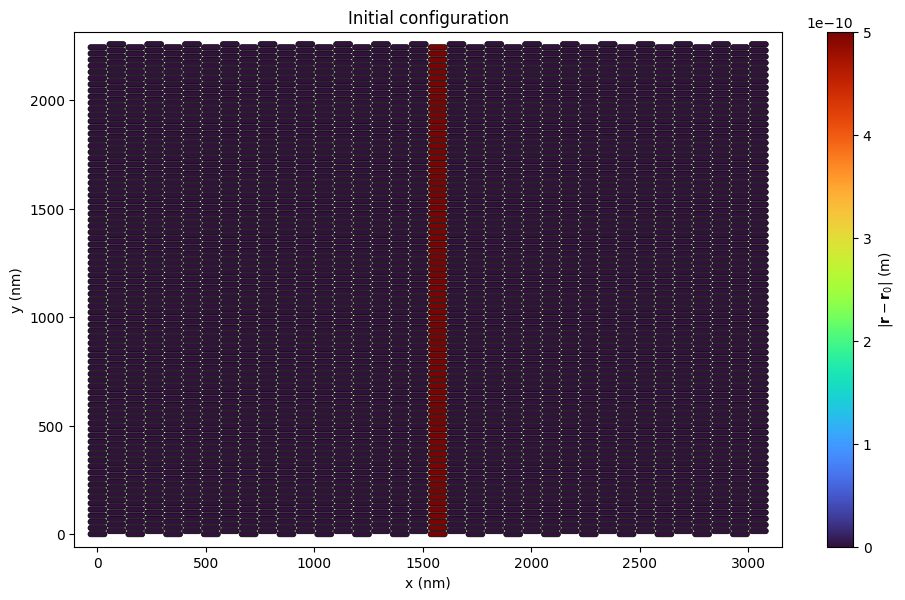

In [7]:
vmax = np.max(np.linalg.norm(u_profiles, axis=2))

fig, ax = plot_lattice(
    pos_profiles[0],
    theta_profiles[0],
    u_profiles[0],
    L, d,
    vmax=vmax,
    title="Initial configuration"
)

plt.show()

## Preliminary results

The simulated nanorod configuration can be visualized at a selected time after the initial excitation.

The color of each nanorod represents the magnitude of its center-of-mass displacement,

$$
|\mathbf{u}_i| = |\mathbf{r}_i-\mathbf{r}_{i,0}|.
$$

The same color scale is used for all simulation times, allowing the displacement amplitude to be compared between different frames.

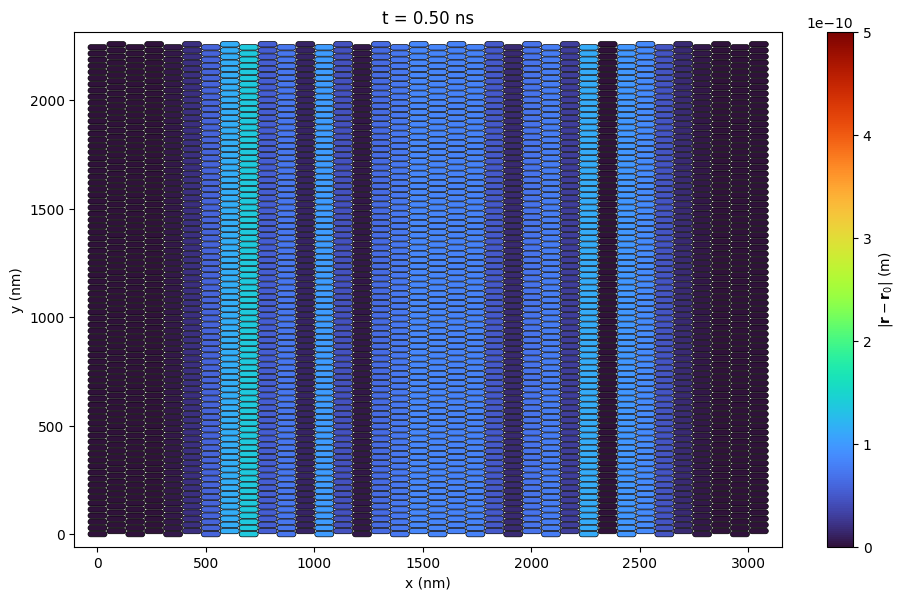

In [8]:
target_time = 0.5e-9  # s # change this parameter

frame = np.abs(time_profiles-target_time).argmin()

fig, ax = plot_lattice(
    pos_profiles[frame],
    theta_profiles[frame],
    u_profiles[frame],
    L, d,
    vmax=vmax,
    title=f"t = {time_profiles[frame]*1e9:.2f} ns"
)

plt.show()